# Project Flow

Minimal notebook to call the implemented functions and inspect the flow:

`manifest -> dataloaders -> ResNet50 -> forward pass -> optional training -> XAI`

## 1. Setup

In [1]:
from pathlib import Path
import csv
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data" / "OxfordPets"
MANIFEST = DATA_ROOT / "oxford_pets_manifest.csv"
DEBUG_MANIFEST = DATA_ROOT / "oxford_pets_manifest_debug.csv"

CHECKPOINT = PROJECT_ROOT / "outputs" / "checkpoints" / "best_resnet50_oxford_pets.pt"
XAI_OUTPUT = PROJECT_ROOT / "outputs" / "figures" / "xai_examples.png"
XAI_READING_OUTPUT = PROJECT_ROOT / "outputs" / "figures" / "xai_gradient_reading.png"
XAI_MULTI_OUTPUT = PROJECT_ROOT / "outputs" / "figures" / "xai_multi_class_comparison.png"
XAI_METRICS_OUTPUT = PROJECT_ROOT / "outputs" / "reports" / "xai_metrics.csv"

USE_DEBUG = False
RUN_TRAINING = False
RUN_XAI = CHECKPOINT.exists()
BATCH_SIZE = 8
NUM_WORKERS = 0
SEED = 42
XAI_MAX_IMAGES = 4
XAI_MAX_PER_CLASS = 1
IG_STEPS = 8
IG_INTERNAL_BATCH_SIZE = 4

print(f"project: {PROJECT_ROOT}")
print(f"checkpoint exists: {CHECKPOINT.exists()}")
print(f"RUN_XAI: {RUN_XAI}")
print(f"xai reading output: {XAI_READING_OUTPUT}")
print(f"xai multi-class output: {XAI_MULTI_OUTPUT}")
print(f"xai metrics output: {XAI_METRICS_OUTPUT}")

project: /home/emma/DeepLearning/Deep_Learning_XAI
checkpoint exists: True
RUN_XAI: True
xai reading output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_gradient_reading.png
xai multi-class output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_multi_class_comparison.png
xai metrics output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/xai_metrics.csv


## 2. Imports

In [2]:
import torch

from src.data import build_dataloaders, denormalize_batch
from src.model import build_resnet50_classifier, get_device, summarize_parameters
from src.utils import set_seed, setup_logging

setup_logging("INFO")
set_seed(SEED)
device = get_device("auto")

print(f"torch: {torch.__version__}")
print(f"device: {device}")

torch: 2.10.0+cu128
device: cpu


## 3. Select Manifest

A manifest is the dataset index used by the code. It is a CSV table that maps each image to its label, split, class name, and trimap path.

Example columns:

```text
filepath, mask_path, label, class_name, species, split
```

Create it first with:

```bash
python3 scripts/prepare_oxford_pets.py --data-root data/OxfordPets --download
```

In [3]:
if USE_DEBUG and DEBUG_MANIFEST.exists():
    manifest = DEBUG_MANIFEST
elif MANIFEST.exists():
    manifest = MANIFEST
else:
    raise FileNotFoundError("No manifest found. Run prepare_oxford_pets.py first.")

print(manifest)

/home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/oxford_pets_manifest.csv


## 4. Manifest Summary

In [4]:
from collections import Counter

with manifest.open("r", newline="", encoding="utf-8") as handle:
    rows = list(csv.DictReader(handle))

split_counts = Counter(row["split"] for row in rows)
class_counts = Counter(row["class_name"] for row in rows)

print(f"rows: {len(rows)}")
print(f"splits: {dict(split_counts)}")
print(f"classes: {len(class_counts)}")
rows[:2]

rows: 7349
splits: {'test': 3669, 'train': 3129, 'val': 551}
classes: 37


[{'filepath': '/home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/images/Abyssinian_2.jpg',
  'mask_path': '/home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/annotations/trimaps/Abyssinian_2.png',
  'label': '0',
  'class_name': 'Abyssinian',
  'species': 'cat',
  'split': 'test',
  'image_id': 'Abyssinian_2',
  'official_class_id': '1',
  'official_species_id': '1',
  'official_breed_id': '1'},
 {'filepath': '/home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/images/Abyssinian_20.jpg',
  'mask_path': '/home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/annotations/trimaps/Abyssinian_20.png',
  'label': '0',
  'class_name': 'Abyssinian',
  'species': 'cat',
  'split': 'test',
  'image_id': 'Abyssinian_20',
  'official_class_id': '1',
  'official_species_id': '1',
  'official_breed_id': '1'}]

## 5. Build DataLoaders

In [5]:
loaders = build_dataloaders(
    manifest_path=manifest,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

images, labels, class_names, image_paths, mask_paths = next(iter(loaders["train"]))

print(f"images: {tuple(images.shape)}")
print(f"labels: {tuple(labels.shape)}")
print(f"first class: {class_names[0]}")
print(f"first image: {image_paths[0]}")
print(f"first trimap: {mask_paths[0]}")
print(f"normalized range: {images.min().item():.3f} -> {images.max().item():.3f}")

2026-07-03 08:23:14 | INFO | src.data | Loaded Oxford-IIIT Pet split=train with 3129 samples and 37 visible classes
2026-07-03 08:23:15 | INFO | src.data | Loaded Oxford-IIIT Pet split=val with 551 samples and 37 visible classes
2026-07-03 08:23:15 | INFO | src.data | Loaded Oxford-IIIT Pet split=test with 3669 samples and 37 visible classes


images: (8, 3, 224, 224)
labels: (8,)
first class: great_pyrenees
first image: /home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/images/great_pyrenees_183.jpg
first trimap: /home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/annotations/trimaps/great_pyrenees_183.png
normalized range: -2.118 -> 2.640


## 6. Inspect One Batch

In [6]:
denorm = denormalize_batch(images).clamp(0, 1)

print(f"denormalized range: {denorm.min().item():.3f} -> {denorm.max().item():.3f}")
print(f"batch classes: {list(class_names)}")

denormalized range: 0.000 -> 1.000
batch classes: ['great_pyrenees', 'pug', 'Abyssinian', 'yorkshire_terrier', 'american_bulldog', 'staffordshire_bull_terrier', 'chihuahua', 'english_cocker_spaniel']


### What the preprocessing does

Original Oxford images can have different sizes. The DataLoader applies the ResNet preprocessing defined in `src/data.py`:

```text
Resize(256) -> CenterCrop(224) -> ToTensor() -> ImageNet Normalize
```

So every image given to ResNet has shape:

```text
3 x 224 x 224
```

That means `224 * 224 = 50,176` spatial pixels, with 3 RGB channels. The trimap is loaded from the dataset and resized to `224 x 224` only for inspection/alignment with the preprocessed image.

## 7. Inspect Trimap

A trimap is a pixel-level annotation provided by Oxford-IIIT Pet. It separates the image into three regions:

```text
1 = pet / foreground
2 = background
3 = boundary / uncertain edge
```

Later, this lets us perturb only the background while keeping the pet unchanged.

trimap path: /home/emma/DeepLearning/Deep_Learning_XAI/data/OxfordPets/annotations/trimaps/great_pyrenees_183.png
trimap size: (500, 333)
trimap values: [1, 2, 3]
pet pixels: 0.113
background pixels: 0.823
boundary pixels: 0.063


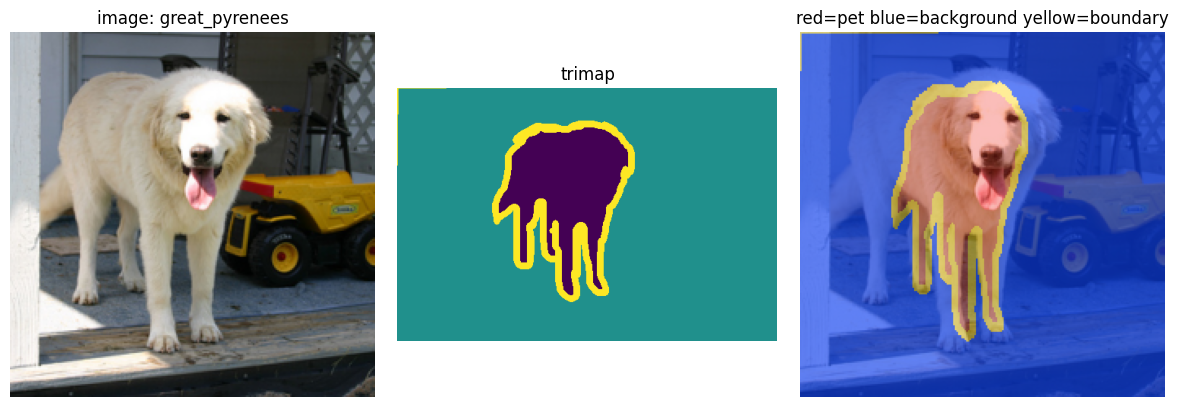

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

idx = 0
image_np = denorm[idx].permute(1, 2, 0).cpu().numpy()
trimap = Image.open(mask_paths[idx])
trimap_np = np.array(trimap)
trimap_resized = np.array(trimap.resize((image_np.shape[1], image_np.shape[0]), Image.NEAREST))

pet_mask = trimap_resized == 1
background_mask = trimap_resized == 2
boundary_mask = trimap_resized == 3

print(f"trimap path: {mask_paths[idx]}")
print(f"trimap size: {trimap.size}")
print(f"trimap values: {sorted(np.unique(trimap_np).tolist())}")
print(f"pet pixels: {pet_mask.mean():.3f}")
print(f"background pixels: {background_mask.mean():.3f}")
print(f"boundary pixels: {boundary_mask.mean():.3f}")

overlay = image_np.copy()
overlay[background_mask] = overlay[background_mask] * 0.35 + np.array([0.05, 0.25, 0.95]) * 0.65
overlay[pet_mask] = overlay[pet_mask] * 0.70 + np.array([0.95, 0.15, 0.10]) * 0.30
overlay[boundary_mask] = overlay[boundary_mask] * 0.55 + np.array([1.00, 0.85, 0.10]) * 0.45

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_np)
axes[0].set_title(f"image: {class_names[idx]}")
axes[1].imshow(trimap_np, cmap="viridis")
axes[1].set_title("trimap")
axes[2].imshow(np.clip(overlay, 0, 1))
axes[2].set_title("red=pet blue=background yellow=boundary")
for axis in axes:
    axis.axis("off")
plt.tight_layout()

## 8. Build Model

In [8]:
num_classes = len(class_counts)

try:
    model = build_resnet50_classifier(num_classes=num_classes, pretrained=True)
except Exception as exc:
    print(f"pretrained weights unavailable: {exc}")
    model = build_resnet50_classifier(num_classes=num_classes, pretrained=False)

print(summarize_parameters(model))

2026-07-03 08:23:33 | INFO | src.model | Built ResNet50 classifier: num_classes=37 pretrained=True total_params=23583845 trainable=22138917 frozen=1444928
2026-07-03 08:23:33 | INFO | src.model | Module conv1    trainable_params=0 total_params=9408 trainable=False
2026-07-03 08:23:33 | INFO | src.model | Module bn1      trainable_params=0 total_params=128 trainable=False
2026-07-03 08:23:33 | INFO | src.model | Module layer1   trainable_params=0 total_params=215808 trainable=False
2026-07-03 08:23:33 | INFO | src.model | Module layer2   trainable_params=0 total_params=1219584 trainable=False
2026-07-03 08:23:33 | INFO | src.model | Module layer3   trainable_params=7098368 total_params=7098368 trainable=True
2026-07-03 08:23:33 | INFO | src.model | Module layer4   trainable_params=14964736 total_params=14964736 trainable=True
2026-07-03 08:23:33 | INFO | src.model | Module fc       trainable_params=75813 total_params=75813 trainable=True


ModelSummary(total_params=23583845, trainable_params=22138917, frozen_params=1444928)


## 9. Forward Pass

In [9]:
model = model.to(device).eval()

with torch.no_grad():
    logits = model(images.to(device))

print(f"logits: {tuple(logits.shape)}")
print(f"predictions: {logits.argmax(dim=1).cpu().tolist()}")

logits: (8, 37)
predictions: [10, 10, 13, 13, 13, 13, 13, 17]


## 10. Optional Training

In [10]:
if RUN_TRAINING:
    cmd = [
        sys.executable,
        "scripts/train_baseline.py",
        "--manifest", str(manifest),
        "--batch-size", "16",
        "--epochs", "5",
        "--patience", "2",
    ]
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("training skipped")

training skipped


## 11. XAI Theory and Function Calls

If the checkpoint exists, this notebook sets `RUN_XAI=True` automatically and calls the implemented Grad-CAM and Integrated Gradients functions.

Integrated Gradients is memory-heavy because it evaluates many interpolated versions of each image. Keep `XAI_MAX_IMAGES=1` and `IG_STEPS=8` while debugging the notebook; increase to `IG_STEPS=50` only for final figures, preferably on GPU.

### What saliency methods are for

A classifier gives us a class prediction, but not a reason. Saliency methods try to assign an importance value to image regions or pixels for one target class. They do not prove causality by themselves: they are diagnostic tools. In this project we use them critically, asking whether the model looks at the pet morphology or at background/context.

### Vanilla input gradients

For an image `x` and target class `c`, the model produces a score `S_c(x)`. Vanilla gradients compute:

```text
dS_c(x) / dx
```

This answers: if I changed each input pixel by a tiny amount, how much would the class score change? High absolute gradient means high local sensitivity. The sign also matters: positive values push the class score up, negative values push it down. These maps are useful because they expose the raw derivative, but they are often noisy and very local.

### Grad-CAM

Grad-CAM does not work directly on input pixels. It looks at a late convolutional layer, here `model.layer4[-1]` in ResNet50. At that point the spatial grid is coarse, usually around `7 x 7`, but the channels encode more semantic visual patterns.

The method computes gradients of the class score with respect to these feature maps, averages the gradients spatially to get one importance weight per channel, then combines the feature maps with those weights:

```text
Grad-CAM = ReLU(sum_k weight_k * feature_map_k)
```

The result is upsampled back to `224 x 224`. This is why Grad-CAM is smoother and more region-level than vanilla gradients. It tells us which late convolutional regions supported the class score, but it can hide fine details and can look convincing even when the highlighted region is semantically wrong.

### Integrated Gradients

Integrated Gradients tries to avoid relying on only one local gradient at the final image. It defines a path from a baseline image to the real image and accumulates gradients along that path:

```text
baseline -> image
```

In this project the baseline is not black. We use a heavily blurred version of the same image. This preserves average color and brightness while removing sharp pet details. That is important because a black image can be out-of-distribution and may create misleading attributions.

Intuitively, Integrated Gradients asks: as the image becomes less blurred and more like the real input, which pixels accumulate evidence for the class?

### What to look for

Use the trimap as the visual reference. If saliency is mostly inside the pet region, the explanation is morphologically plausible. If it falls on background, borders, lighting, floor, grass, furniture, or texture, the model may be exploiting spurious correlations. That failure mode is the central object of this project.

In [11]:
from scripts.run_xai import collect_correct_examples, load_checkpoint, load_class_names
from src.xai import (
    GradCAM,
    input_gradient_maps,
    integrated_gradients_maps,
    log_tensor_stats,
    overlay_heatmap,
    saliency_concentration,
    saliency_iou_at_percentile,
    save_multi_xai_grid,
    save_xai_grid,
    spearman_rank_correlation,
    write_xai_metrics_csv,
)

print(f"checkpoint: {CHECKPOINT}")
print(f"xai output: {XAI_OUTPUT}")

/home/emma/DeepLearning/.venvDeepLearning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_oxford_pets.pt
xai output: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_examples.png


In [12]:
if RUN_XAI:
    if not CHECKPOINT.exists():
        raise FileNotFoundError("Train the baseline first, then rerun this cell.")

    class_names_by_label = load_class_names(manifest)
    load_checkpoint(model, CHECKPOINT, device)
    model = model.to(device).eval()

    xai_images, xai_labels, true_names, _, confidences, xai_image_paths, xai_mask_paths = collect_correct_examples(
        model=model,
        loader=loaders["test"],
        device=device,
        max_images=XAI_MAX_IMAGES,
        max_per_class=XAI_MAX_PER_CLASS,
    )
    pred_names = [class_names_by_label[int(label.item())] for label in xai_labels]

    log_tensor_stats("notebook.xai_images", xai_images)
    print(f"targets: {[int(label.item()) for label in xai_labels]}")
else:
    print("XAI skipped")

2026-07-03 08:24:03 | INFO | run_xai | Loaded checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_oxford_pets.pt
2026-07-03 08:24:32 | INFO | src.xai | notebook.xai_images shape=(4, 3, 224, 224) min=-2.117904 max=2.248908 mean=-0.576341 std=0.951259


targets: [0, 1, 2, 3]


In [13]:
if RUN_XAI:
    vanilla_maps, raw_input_gradients = input_gradient_maps(model, xai_images, xai_labels)

    gradcam = GradCAM(model, model.layer4[-1])
    try:
        gradcam_maps = gradcam(xai_images, xai_labels)
    finally:
        gradcam.close()

    ig_maps = integrated_gradients_maps(
        model=model,
        inputs=xai_images,
        targets=xai_labels,
        steps=IG_STEPS,
        internal_batch_size=IG_INTERNAL_BATCH_SIZE,
        baseline_type="blurred",
    )

    ig_black_maps = integrated_gradients_maps(
        model=model,
        inputs=xai_images,
        targets=xai_labels,
        steps=IG_STEPS,
        internal_batch_size=IG_INTERNAL_BATCH_SIZE,
        baseline_type="black",
    )

    save_xai_grid(
        images=xai_images,
        gradcam_maps=gradcam_maps,
        ig_maps=ig_maps,
        class_names=true_names,
        predictions=pred_names,
        confidences=confidences,
        output_path=XAI_OUTPUT,
    )
    print(f"saved: {XAI_OUTPUT}")

    save_multi_xai_grid(
        images=xai_images,
        vanilla_maps=vanilla_maps,
        gradcam_maps=gradcam_maps,
        ig_blur_maps=ig_maps,
        ig_black_maps=ig_black_maps,
        class_names=true_names,
        predictions=pred_names,
        confidences=confidences,
        output_path=XAI_MULTI_OUTPUT,
    )
    print(f"saved: {XAI_MULTI_OUTPUT}")
else:
    print("XAI maps skipped")

2026-07-03 08:26:00 | INFO | src.xai | vanilla_gradients.raw shape=(4, 3, 224, 224) min=-0.619152 max=0.656262 mean=-0.000002 std=0.025003
2026-07-03 08:26:00 | INFO | src.xai | vanilla_gradients.map shape=(4, 1, 224, 224) min=0.000000 max=1.000000 mean=0.043380 std=0.055469
2026-07-03 08:26:01 | INFO | src.xai | gradcam.activations shape=(4, 2048, 7, 7) min=0.000000 max=106.570930 mean=0.293324 std=1.685930
2026-07-03 08:26:01 | INFO | src.xai | gradcam.gradients shape=(4, 2048, 7, 7) min=-0.000806 max=0.000608 mean=-0.000061 std=0.000295
2026-07-03 08:26:01 | INFO | src.xai | gradcam.map shape=(4, 1, 224, 224) min=0.000000 max=1.000000 mean=0.156456 std=0.236916
2026-07-03 08:26:01 | INFO | src.xai | ig.blurred_baseline shape=(4, 3, 224, 224) min=-1.741159 max=1.785970 mean=-0.579147 std=0.785853
2026-07-03 08:26:06 | INFO | src.xai | ig.attributions shape=(4, 3, 224, 224) min=-0.541625 max=0.445463 mean=0.000035 std=0.011434
2026-07-03 08:26:06 | INFO | src.xai | ig.map shape=(4, 1,

saved: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_examples.png


2026-07-03 08:26:17 | INFO | src.xai | Saved multi-XAI grid: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_multi_class_comparison.png


saved: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_multi_class_comparison.png


## 12. XAI Metrics

These metrics turn the visual comparison into numbers:

- `foreground_mass`: fraction of saliency inside the pet trimap region.
- `background_mass`: fraction of saliency inside the background trimap region.
- `ig_blur_vs_black_top20_iou`: overlap between the top 20% most salient pixels using blurred vs black IG baselines.
- `ig_blur_vs_black_spearman`: rank correlation between the full blurred-baseline and black-baseline IG maps.

For this project, high background mass or low baseline agreement are warning signs: the explanation may be sensitive to context or to methodological choices.

In [14]:
if RUN_XAI:
    import pandas as pd

    gradcam_concentration = saliency_concentration(gradcam_maps, xai_mask_paths)
    vanilla_concentration = saliency_concentration(vanilla_maps, xai_mask_paths)
    ig_blur_concentration = saliency_concentration(ig_maps, xai_mask_paths)
    ig_black_concentration = saliency_concentration(ig_black_maps, xai_mask_paths)
    ig_iou = saliency_iou_at_percentile(ig_maps, ig_black_maps, percentile=80.0).detach().cpu()
    ig_spearman = spearman_rank_correlation(ig_maps, ig_black_maps).detach().cpu()

    metric_rows = []
    for row_idx, label in enumerate(xai_labels.detach().cpu().tolist()):
        row = {
            "index": row_idx,
            "label": int(label),
            "class_name": true_names[row_idx],
            "prediction": pred_names[row_idx],
            "confidence": confidences[row_idx],
            "ig_blur_vs_black_top20_iou": float(ig_iou[row_idx].item()),
            "ig_blur_vs_black_spearman": float(ig_spearman[row_idx].item()),
        }
        for prefix, values in [
            ("vanilla", vanilla_concentration[row_idx]),
            ("gradcam", gradcam_concentration[row_idx]),
            ("ig_blur", ig_blur_concentration[row_idx]),
            ("ig_black", ig_black_concentration[row_idx]),
        ]:
            row[f"{prefix}_foreground_mass"] = values["foreground_saliency_mass"]
            row[f"{prefix}_background_mass"] = values["background_saliency_mass"]
            row[f"{prefix}_boundary_mass"] = values["boundary_saliency_mass"]
        metric_rows.append(row)

    write_xai_metrics_csv(metric_rows, XAI_METRICS_OUTPUT)
    metrics_df = pd.DataFrame(metric_rows)
    display(metrics_df.sort_values("gradcam_background_mass", ascending=False))
else:
    print("metrics skipped")

2026-07-03 08:26:24 | INFO | src.xai | Saved XAI metrics: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/xai_metrics.csv


,index,label,class_name,prediction,confidence,ig_blur_vs_black_top20_iou,ig_blur_vs_black_spearman,vanilla_foreground_mass,vanilla_background_mass,vanilla_boundary_mass,gradcam_foreground_mass,gradcam_background_mass,gradcam_boundary_mass,ig_blur_foreground_mass,ig_blur_background_mass,ig_blur_boundary_mass,ig_black_foreground_mass,ig_black_background_mass,ig_black_boundary_mass
3,3,3,Bombay,Bombay,0.992266,0.322615,0.556684,0.272667,0.592474,0.134859,0.445283,0.344716,0.210002,0.331543,0.517453,0.151004,0.305426,0.543386,0.151188
0,0,0,Abyssinian,Abyssinian,0.996210,0.383131,0.711783,0.273242,0.628479,0.098279,0.486731,0.339483,0.173787,0.345446,0.526082,0.128473,0.351256,0.498684,0.150060
1,1,1,Bengal,Bengal,0.860228,0.215674,0.341468,0.165302,0.737528,0.097170,0.603973,0.194927,0.201100,0.364654,0.416480,0.218866,0.259218,0.604081,0.136701
2,2,2,Birman,Birman,0.397894,0.345308,0.541476,0.502477,0.368154,0.129369,0.694833,0.155853,0.149315,0.596177,0.306834,0.096988,0.619481,0.280637,0.099883


## 13. Read the Explanations

The next plot makes the gradients explicit.

- `Vanilla gradient` is very local and noisy: it shows immediate sensitivity of the class score to each input pixel.
- `Grad-CAM` is coarse because it is computed from `layer4[-1]`, where ResNet has a 7 x 7 spatial grid before upsampling.
- `Integrated Gradients` is usually smoother because it sums gradients along the path from the blurred baseline to the real image.
- `Raw dScore/dR`, `dScore/dG`, `dScore/dB` are the signed channel gradients. Bright positive/negative regions mean the class score is sensitive to that channel there.

For the saliency-map illusion argument, compare the hot regions with the trimap: heat on the animal supports a morphology-based explanation; heat on background supports the spurious-correlation critique.

saved explanation plot: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/xai_gradient_reading.png


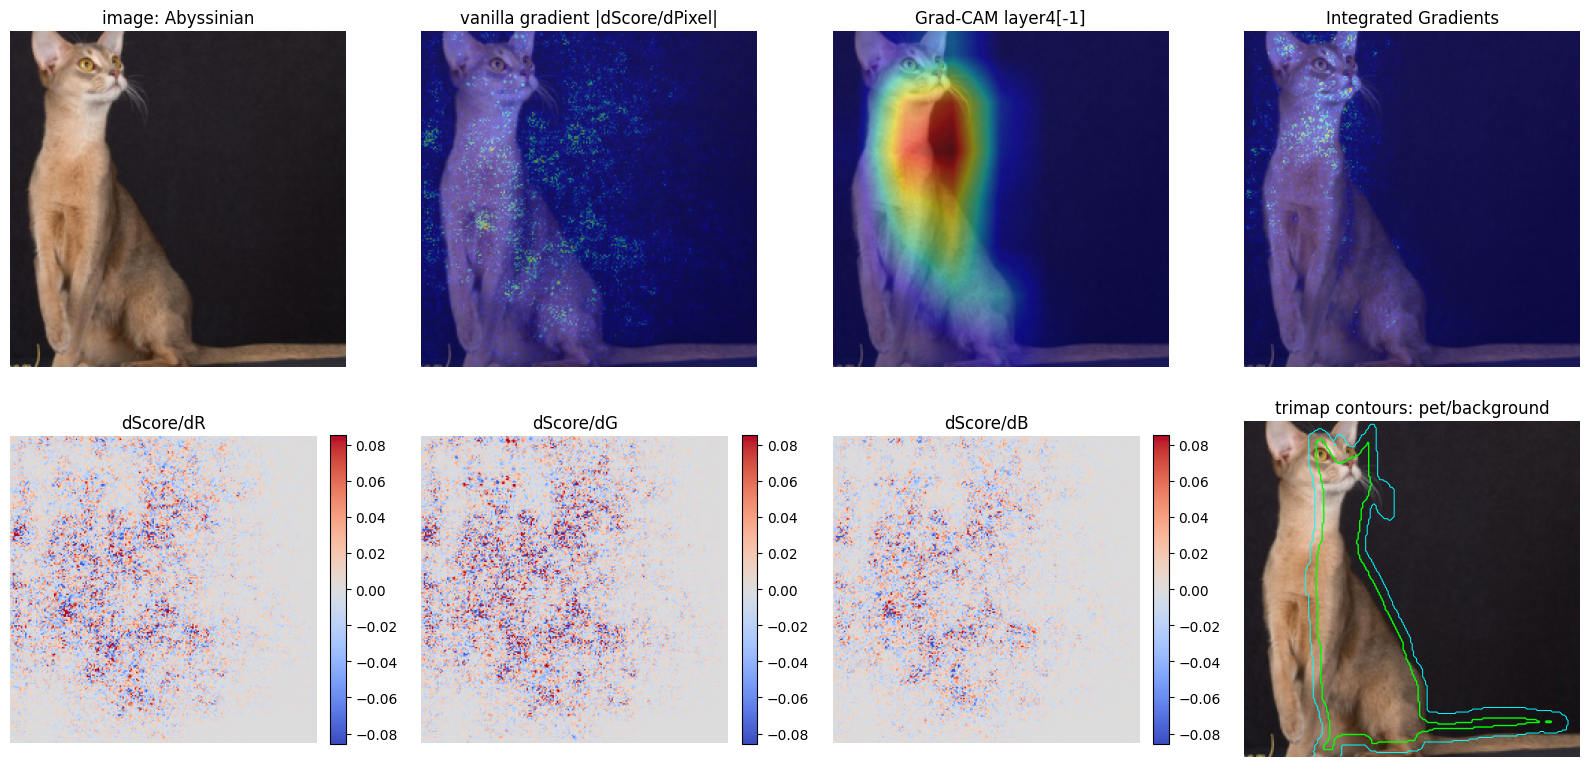

In [15]:
if RUN_XAI:
    sample_idx = 0
    image_np = denormalize_batch(xai_images.detach().cpu()).clamp(0, 1)[sample_idx].permute(1, 2, 0).numpy()
    vanilla_np = vanilla_maps[sample_idx, 0].detach().cpu().numpy()
    gradcam_np = gradcam_maps[sample_idx, 0].detach().cpu().numpy()
    ig_np = ig_maps[sample_idx, 0].detach().cpu().numpy()
    raw_grad = raw_input_gradients[sample_idx].detach().cpu()
    raw_grad_np = raw_grad.numpy()
    channel_limit = float(np.percentile(np.abs(raw_grad_np), 99))
    channel_limit = max(channel_limit, 1e-8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes[0, 0].imshow(image_np)
    axes[0, 0].set_title(f"image: {true_names[sample_idx]}")
    axes[0, 1].imshow(overlay_heatmap(image_np, vanilla_np))
    axes[0, 1].set_title("vanilla gradient |dScore/dPixel|")
    axes[0, 2].imshow(overlay_heatmap(image_np, gradcam_np))
    axes[0, 2].set_title("Grad-CAM layer4[-1]")
    axes[0, 3].imshow(overlay_heatmap(image_np, ig_np))
    axes[0, 3].set_title("Integrated Gradients")

    for channel, name in enumerate(["dScore/dR", "dScore/dG", "dScore/dB"]):
        im = axes[1, channel].imshow(raw_grad_np[channel], cmap="coolwarm", vmin=-channel_limit, vmax=channel_limit)
        axes[1, channel].set_title(name)
        fig.colorbar(im, ax=axes[1, channel], fraction=0.046, pad=0.04)

    trimap = Image.open(xai_mask_paths[sample_idx])
    trimap_resized = np.array(trimap.resize((image_np.shape[1], image_np.shape[0]), Image.NEAREST))
    axes[1, 3].imshow(image_np)
    axes[1, 3].contour(trimap_resized == 1, colors="lime", linewidths=1.0)
    axes[1, 3].contour(trimap_resized == 2, colors="cyan", linewidths=0.7)
    axes[1, 3].set_title("trimap contours: pet/background")

    for axis in axes.ravel():
        axis.axis("off")
    plt.tight_layout()
    XAI_READING_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(XAI_READING_OUTPUT, dpi=160, bbox_inches="tight")
    print(f"saved explanation plot: {XAI_READING_OUTPUT}")
else:
    print("explanation plot skipped")